In [26]:
import pandas as pd
import numpy as np

In [27]:
df = pd.read_csv('ForeignGifts_edu.csv')
df.head()

,ID,OPEID,Institution Name,City,State,Foreign Gift Received Date,Foreign Gift Amount,Gift Type,Country of Giftor,Giftor Name
0,1,102000,Jacksonville State University,Jacksonville,AL,43738,250000,Monetary Gift,CHINA,NaN
1,2,104700,Troy University,Troy,AL,43592,463657,Contract,CHINA,Confucius Institute Headquarters
2,3,105100,University of Alabama,Tuscaloosa,AL,43466,3649107,Contract,ENGLAND,Springer Nature Customer Service Ce
3,4,105100,University of Alabama,Tuscaloosa,AL,43472,1000,Contract,SAUDI ARABIA,Saudi Arabia Education Mission
4,5,105100,University of Alabama,Tuscaloosa,AL,43479,49476,Contract,SAUDI ARABIA,Saudi Arabia Education Mission


In [28]:
uva = df[
    df["Institution Name"]
    .str.contains("University of Virginia|UVA", case=False, na=False)
]

top_10_countries_uva = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
    .sum()
    .nlargest(10)
    .reset_index(name="Total Gift Amount")
)

top_10_countries_uva

,Country of Giftor,Total Gift Amount
0,BANGLADESH,4228589
1,SWEDEN,4007552
2,TANZANIA,2776447
3,SWITZERLAND,2000000
4,ENGLAND,1950666
5,GUERNSEY,1500000
6,FINLAND,1008384
7,BERMUDA,900000
8,KOREA,862787
9,SINGAPORE,805000


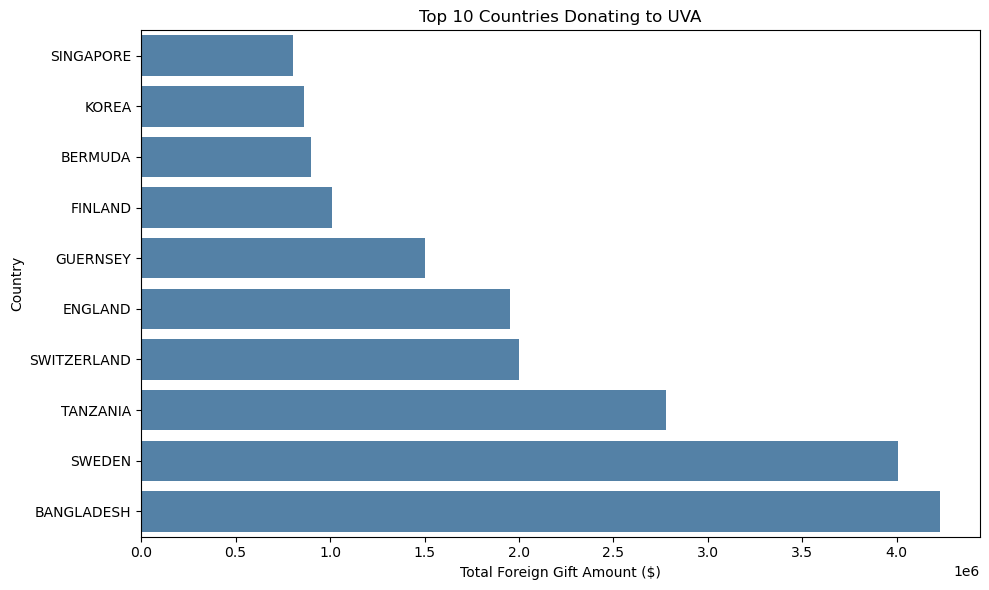

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

plot_data = top_10_countries_uva.sort_values("Total Gift Amount")

plt.figure(figsize=(10, 6))
sns.barplot(
    data=plot_data,
    x="Total Gift Amount",
    y="Country of Giftor",
    color="steelblue"
)

plt.xlabel("Total Foreign Gift Amount ($)")
plt.ylabel("Country")
plt.title("Top 10 Countries Donating to UVA")
plt.tight_layout()
plt.show()

No apparent similarities amongst top countries. 

In [30]:
country_totals_uva = (
    uva.groupby("Country of Giftor")["Foreign Gift Amount"]
        .sum()
        .sort_values(ascending=False)
        .reset_index(name="Total Gift Amount")
)

total_uva_donations = country_totals_uva["Total Gift Amount"].sum()

top_20_countries_uva = country_totals_uva.head(20).copy()
top_20_countries_uva["Percent of UVA Donations"] = (
    top_20_countries_uva["Total Gift Amount"] / total_uva_donations * 100
)

top_20_countries_uva

,Country of Giftor,Total Gift Amount,Percent of UVA Donations
0,BANGLADESH,4228589,19.056937
1,SWEDEN,4007552,18.060791
2,TANZANIA,2776447,12.512584
3,SWITZERLAND,2000000,9.013378
4,ENGLAND,1950666,8.791045
5,GUERNSEY,1500000,6.760034
6,FINLAND,1008384,4.544473
7,BERMUDA,900000,4.056020
8,KOREA,862787,3.888313
9,SINGAPORE,805000,3.627885


In [31]:
2/3 of our money comes from 5 countries let's see how that compares to other top nations. 

SyntaxError: unterminated string literal (detected at line 1) (4077794997.py, line 1)

In [ ]:
institution_country_totals = (
    df.groupby(["Institution Name", "Country of Giftor"])["Foreign Gift Amount"]
      .sum()
      .reset_index()
)

top_20_institutions = (
    institution_country_totals.groupby("Institution Name")["Foreign Gift Amount"]
    .sum()
    .nlargest(20)
    .index
)

results = []

for institution in top_20_institutions:
    institution_data = institution_country_totals[
        institution_country_totals["Institution Name"] == institution
    ].sort_values("Foreign Gift Amount", ascending=False)

    total_donations = institution_data["Foreign Gift Amount"].sum()
    top_5 = institution_data.head(5)

    results.append({
        "Institution Name": institution,
        "Total Donations": total_donations,
        "Top 5 Country Donations": top_5["Foreign Gift Amount"].sum(),
        "Percent from Top 5 Countries": (
            top_5["Foreign Gift Amount"].sum() / total_donations * 100
        ),
        "Top 5 Countries": ", ".join(top_5["Country of Giftor"])
    })

top_20_top_5_analysis = (
    pd.DataFrame(results)
    .sort_values("Total Donations", ascending=False)
)

top_20_top_5_analysis

,Institution Name,Total Donations,Top 5 Country Donations,Percent from Top 5 Countries,Top 5 Countries
0,Carnegie Mellon University,1477922504,1306347076,88.390770,"BERMUDA, QATAR, THAILAND, INDIA, JAPAN"
1,Cornell University,1289937761,1151072308,89.234717,"QATAR, INDIA, HONG KONG, CHINA, CANADA"
2,Harvard University,954803610,513295910,53.759318,"ENGLAND, HONG KONG, CHINA, SWITZERLAND, INDIA"
3,Massachusetts Institute of Technology,859071692,434699151,50.601033,"SINGAPORE, SAUDI ARABIA, RUSSIA, ENGLAND, HONG..."
4,Yale University,613441311,422602817,68.890505,"HONG KONG, ENGLAND, CHINA, SWITZERLAND, SPAIN"
5,Texas A&M University,521455050,520125057,99.744946,"QATAR, SAUDI ARABIA, CHINA, POLAND, ENGLAND"
6,Johns Hopkins University,502409595,259525708,51.656201,"ENGLAND, SWITZERLAND, MONACO, CANADA, JAPAN"
7,Northwestern University,402316221,350614176,87.148904,"QATAR, SAUDI ARABIA, INDONESIA, SWITZERLAND, C..."
8,Georgetown University,379950511,352458434,92.764301,"QATAR, HONG KONG, ENGLAND, SAUDI ARABIA, FRANCE"
9,University of Chicago (The),364544338,267987312,73.512954,"ENGLAND, CHINA, HONG KONG, SINGAPORE, CHILE"


Only England of top 10 donates to UVA

In [ ]:
acc_schools = {
    "Boston College": r"Boston College",
    "California": r"University of California|Berkeley",
    "Clemson": r"Clemson University",
    "Duke": r"Duke University",
    "Florida State": r"Florida State University",
    "Georgia Tech": r"Georgia Institute of Technology|Georgia Tech",
    "Louisville": r"University of Louisville",
    "Miami": r"University of Miami",
    "NC State": r"North Carolina State University|NC State",
    "North Carolina": r"University of North Carolina",
    "Notre Dame": r"University of Notre Dame|Notre Dame",
    "Pittsburgh": r"University of Pittsburgh",
    "SMU": r"Southern Methodist University|SMU",
    "Stanford": r"Stanford University",
    "Syracuse": r"Syracuse University",
    "Virginia": r"University of Virginia",
    "Virginia Tech": r"Virginia Polytechnic|Virginia Tech",
    "Wake Forest": r"Wake Forest University"
}

acc_results = []

for school, pattern in acc_schools.items():
    school_data = df[
        df["Institution Name"].str.contains(
            pattern, case=False, na=False, regex=True
        )
    ]

    acc_results.append({
        "School": school,
        "Total Donations": school_data["Foreign Gift Amount"].sum()
    })

acc_totals = (
    pd.DataFrame(acc_results)
    .sort_values("Total Donations", ascending=False)
    .reset_index(drop=True)
)

acc_totals["Rank"] = acc_totals.index + 1

acc_totals[["Rank", "School", "Total Donations"]]

,Rank,School,Total Donations
0,1,California,839372693
1,2,Duke,343699498
2,3,Stanford,319561362
3,4,Georgia Tech,77979361
4,5,Pittsburgh,49024123
5,6,Boston College,48995451
6,7,Notre Dame,46652439
7,8,North Carolina,44722418
8,9,NC State,23762788
9,10,Virginia,22189238


Appears to be a correlation between academic ranking and donations


In [ ]:
number_of_schools = df["Institution Name"].nunique()

print(f"Number of schools: {number_of_schools}")

Number of schools: 318


In [ ]:
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import seaborn as sns

academic_ranks = {
    "Stanford": 1, "Vanderbilt": 2, "Duke": 3, "UCLA": 4,
    "Northwestern": 5, "Michigan": 6, "California": 7,
    "Notre Dame": 8, "USC": 9, "Virginia": 10, "Florida": 11,
    "Georgia Tech": 12, "North Carolina": 13, "Texas": 14,
    "Illinois": 15, "Boston College": 16, "Wisconsin": 17,
    "Maryland": 18, "Georgia": 19, "Washington": 20,
    "Texas A&M": 21, "Purdue": 22, "Florida State": 23,
    "Ohio State": 24, "Miami": 25, "Virginia Tech": 26,
    "Wake Forest": 27, "NC State": 28, "Rutgers": 29,
    "BYU": 30, "Minnesota": 31, "Clemson": 32,
    "Michigan State": 33, "Indiana": 34, "SMU": 35,
    "TCU": 36, "Pittsburgh": 37, "Oklahoma": 38,
    "Auburn": 39, "Penn State": 40, "UCF": 41,
    "Syracuse": 42, "Arizona State": 43, "Colorado": 43,
    "Utah": 45, "Tennessee": 46, "Iowa": 47,
    "Missouri": 48, "Arizona": 49, "South Carolina": 50,
    "Iowa State": 50, "Houston": 52, "Baylor": 53,
    "Texas Tech": 54, "Kansas": 54, "Oklahoma State": 56,
    "Kansas State": 57, "Oregon": 58, "Arkansas": 59,
    "Alabama": 60, "Ole Miss": 61, "Nebraska": 62,
    "LSU": 63, "Kentucky": 64, "Cincinnati": 65,
    "Mississippi State": 66, "Louisville": 67,
    "West Virginia": 68
}

conference_schools = {
    "ACC": [
        "Stanford", "California", "Duke", "Notre Dame", "Virginia",
        "Georgia Tech", "North Carolina", "Boston College", "Florida State",
        "Miami", "Virginia Tech", "Wake Forest", "NC State", "Clemson",
        "SMU", "Pittsburgh", "Syracuse", "Louisville"
    ],
    "Big Ten": [
        "UCLA", "Northwestern", "Michigan", "Illinois", "Wisconsin",
        "Maryland", "Washington", "Ohio State", "Rutgers", "Minnesota",
        "Purdue", "Penn State", "Michigan State", "Indiana", "Oregon"
    ],
    "SEC": [
        "Vanderbilt", "Florida", "Texas", "Georgia", "Texas A&M",
        "Tennessee", "Missouri", "Oklahoma", "Auburn", "Alabama",
        "Ole Miss", "Arkansas", "LSU", "Kentucky", "Mississippi State",
        "South Carolina"
    ],
    "Big 12": [
        "BYU", "TCU", "UCF", "Arizona State", "Colorado", "Utah",
        "Arizona", "Iowa State", "Texas Tech", "Kansas", "Oklahoma State",
        "Kansas State", "Houston", "Baylor", "Cincinnati", "West Virginia"
    ]
}

school_patterns = {
    "California": r"University of California, Berkeley|University of California Berkeley|Berkeley",
    "UCLA": r"University of California, Los Angeles|UCLA",
    "USC": r"University of Southern California|USC",
    "Miami": r"University of Miami",
    "Virginia": r"University of Virginia",
    "North Carolina": r"University of North Carolina",
    "Texas": r"University of Texas",
    "Georgia": r"University of Georgia",
    "Florida": r"University of Florida",
    "Arizona": r"University of Arizona",
    "Colorado": r"University of Colorado",
    "Utah": r"University of Utah",
    "Iowa": r"University of Iowa",
    "Kansas": r"University of Kansas",
    "Kentucky": r"University of Kentucky",
    "Nebraska": r"University of Nebraska",
    "Oklahoma": r"University of Oklahoma",
    "Oregon": r"University of Oregon",
    "Maryland": r"University of Maryland",
    "Pittsburgh": r"University of Pittsburgh",
    "Louisville": r"University of Louisville",
    "Cincinnati": r"University of Cincinnati",
    "West Virginia": r"West Virginia University",
    "NC State": r"North Carolina State University|NC State",
    "UCF": r"University of Central Florida|UCF",
    "SMU": r"Southern Methodist University|SMU"
}

school_results = []

for conference, schools in conference_schools.items():
    for school in schools:
        pattern = school_patterns.get(school, school)

        school_data = df[
            df["Institution Name"].str.contains(
                pattern, case=False, na=False, regex=True
            )
        ]

        school_results.append({
            "Conference": conference,
            "School": school,
            "Academic Rank": academic_ranks[school],
            "Total Donations": school_data["Foreign Gift Amount"].sum()
        })

conference_analysis = (
    pd.DataFrame(school_results)
    .sort_values(["Conference", "Academic Rank"])
)

conference_analysis

,Conference,School,Academic Rank,Total Donations
0,ACC,Stanford,1,319561362
2,ACC,Duke,3,343699498
1,ACC,California,7,300379707
3,ACC,Notre Dame,8,46652439
4,ACC,Virginia,10,22189238
...,...,...,...,...
42,SEC,Alabama,60,39354381
43,SEC,Ole Miss,61,0
45,SEC,LSU,63,0
46,SEC,Kentucky,64,24971560


In [ ]:
correlation, p_value = spearmanr(
    conference_analysis["Academic Rank"],
    conference_analysis["Total Donations"]
)

print(f"Spearman correlation: {correlation:.3f}")
print(f"P-value: {p_value:.4f}")

Spearman correlation: -0.455
P-value: 0.0001


## P-value
Major correlation between academic success and total foreign compensation

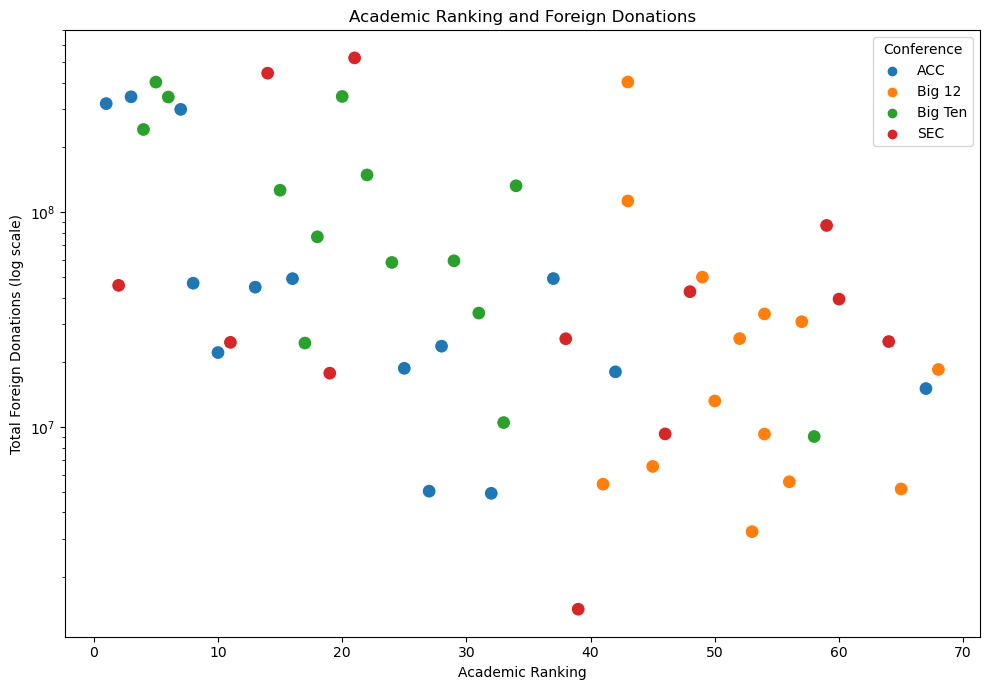

In [ ]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=conference_analysis,
    x="Academic Rank",
    y="Total Donations",
    hue="Conference",
    s=100
)

plt.yscale("log")
plt.xlabel("Academic Ranking")
plt.ylabel("Total Foreign Donations (log scale)")
plt.title("Academic Ranking and Foreign Donations")
plt.tight_layout()
plt.show()

In [39]:
top_30_countries_average = (
    df.groupby("Country of Giftor")["Foreign Gift Amount"]
        .agg(
        Average_Donation="mean",
        Gift_Count="count",
        Total_Donations="sum"
        )
        .sort_values("Average_Donation", ascending=False)
        .head(100)
        .reset_index()
)

top_30_countries_average

,Country of Giftor,Average_Donation,Gift_Count,Total_Donations
0,BERMUDA,7.688837e+06,117,899593972
1,ECUADOR,3.985140e+06,7,27895982
2,QATAR,3.905109e+06,693,2706240869
3,ANTIGUA,3.435545e+06,1,3435545
4,JERSEY,3.064589e+06,6,18387533
...,...,...,...,...
95,TAIWAN,2.897957e+05,381,110412151
96,FRANCE,2.824213e+05,1437,405839396
97,ZAMBIA,2.780331e+05,63,17516086
98,ICELAND,2.692090e+05,2,538418


In [ ]:

middle_east = {
    "BAHRAIN", "IRAN", "IRAQ", "ISRAEL", "JORDAN", "KUWAIT",
    "LEBANON", "OMAN", "QATAR", "SAUDI ARABIA", "SYRIA",
    "UNITED ARAB EMIRATES", "YEMEN", "TURKEY"
}

east_asia = {
    "CHINA", "HONG KONG", "JAPAN", "MACAO", "MONGOLIA",
    "NORTH KOREA", "SOUTH KOREA", "TAIWAN"
}

south_asia = {
    "AFGHANISTAN", "BANGLADESH", "BHUTAN", "INDIA",
    "MALDIVES", "NEPAL", "PAKISTAN", "SRI LANKA"
}

power4_results = []

for conference, schools in conference_schools.items():
    for school in schools:
        pattern = school_patterns.get(school, school)

        school_data = df[
            df["Institution Name"].str.contains(
                pattern, case=False, na=False, regex=True
            )
        ]
        
total_gift_money = country_totals.sum()
top_5_country_money = country_totals.head(5).sum()

percent_top_5 = (
    top_5_country_money / total_gift_money * 100
    if total_gift_money > 0
    else 0
)

        power4_results.append({
            "Conference": conference,
            "School": school,
            "Total Gift Rank": None,
            "Number of Gifts": school_data["Foreign Gift Amount"].count(),
            "Total Gift Money": school_data["Foreign Gift Amount"].sum(),
            "Average Donation": school_data["Foreign Gift Amount"].mean(),
            "Academic Rank": academic_ranks.get(school, np.nan),
            "Middle East Total": school_data.loc[
                school_data["Country of Giftor"].isin(middle_east),
                "Foreign Gift Amount"
            ].sum(),
            "East Asia Total": school_data.loc[
                school_data["Country of Giftor"].isin(east_asia),
                "Foreign Gift Amount"
            ].sum(),
            "South Asia Total": school_data.loc[
                school_data["Country of Giftor"].isin(south_asia),
                "Foreign Gift Amount"
            ].sum()
        })

power4_analysis = (
    pd.DataFrame(power4_results)
    .sort_values("Total Gift Money", ascending=False)
    .reset_index(drop=True)
)

power4_analysis["Total Gift Rank"] = power4_analysis.index + 1

power4_analysis

IndentationError: unexpected indent (269388184.py, line 38)

In [ ]:
power4_analysis = (
    pd.DataFrame(power4_results)
    .query("`Total Gift Money` > 0")
    .sort_values("Total Gift Money", ascending=False)
    .reset_index(drop=True)
)

power4_analysis["Total Gift Rank"] = power4_analysis.index + 1

power4_analysis

,Conference,School,Total Gift Rank,Number of Gifts,Total Gift Money,Average Donation,Academic Rank,Middle East Total,East Asia Total,South Asia Total
0,SEC,Texas A&M,1,376,521455050,1.386849e+06,21,513399952,5691717,0
1,SEC,Texas,2,667,442757457,6.638043e+05,14,16775897,140015248,12369632
2,Big 12,Colorado,3,823,402794902,4.894227e+05,43,333418539,4326718,376038
3,Big Ten,Northwestern,4,251,402316221,1.602853e+06,5,330681516,14602922,869643
4,Big Ten,Washington,5,620,344997397,5.564474e+05,20,136367631,42470928,3069284
5,ACC,Duke,6,145,343699498,2.370341e+06,3,1197635,10345957,7539218
6,Big Ten,Michigan,7,889,342920096,3.857369e+05,6,54120546,80729002,693642
7,ACC,Stanford,8,668,319561362,4.783853e+05,1,8645423,151538270,8350622
8,ACC,California,9,431,300379707,6.969367e+05,7,24425598,90644730,2680551
9,Big Ten,UCLA,10,3916,242146363,6.183513e+04,4,20864869,88361281,250000


In [ ]:
def percent_top_5_countries(school):
    pattern = school_patterns.get(school, school)

    school_data = df[
        df["Institution Name"].str.contains(
            pattern, case=False, na=False, regex=True
        )
    ]

    country_totals = (
        school_data.groupby("Country of Giftor")["Foreign Gift Amount"]
        .sum()
        .sort_values(ascending=False)
    )

    total_money = country_totals.sum()

    return (
        country_totals.head(5).sum() / total_money * 100
        if total_money > 0
        else 0
    )


power4_analysis["Percent from Top 5 Countries"] = (
    power4_analysis["School"].apply(percent_top_5_countries)
)

power4_analysis

,Conference,School,Total Gift Rank,Number of Gifts,Total Gift Money,Average Donation,Academic Rank,Middle East Total,East Asia Total,South Asia Total,Percent from Top 5 Countries
0,SEC,Texas A&M,1,376,521455050,1.386849e+06,21,513399952,5691717,0,99.744946
1,SEC,Texas,2,667,442757457,6.638043e+05,14,16775897,140015248,12369632,61.091557
2,Big 12,Colorado,3,823,402794902,4.894227e+05,43,333418539,4326718,376038,85.983477
3,Big Ten,Northwestern,4,251,402316221,1.602853e+06,5,330681516,14602922,869643,87.148904
4,Big Ten,Washington,5,620,344997397,5.564474e+05,20,136367631,42470928,3069284,65.953455
5,ACC,Duke,6,145,343699498,2.370341e+06,3,1197635,10345957,7539218,83.033352
6,Big Ten,Michigan,7,889,342920096,3.857369e+05,6,54120546,80729002,693642,52.498320
7,ACC,Stanford,8,668,319561362,4.783853e+05,1,8645423,151538270,8350622,65.713947
8,ACC,California,9,431,300379707,6.969367e+05,7,24425598,90644730,2680551,46.744129
9,Big Ten,UCLA,10,3916,242146363,6.183513e+04,4,20864869,88361281,250000,64.191684


In [37]:
israel_results = []

for conference, schools in conference_schools.items():
    for school in schools:
        pattern = school_patterns.get(school, school)

        school_data = df[
            df["Institution Name"].str.contains(
                pattern, case=False, na=False, regex=True
            )
        ]

        israel_amount = school_data.loc[
            school_data["Country of Giftor"].str.upper().eq("ISRAEL"),
            "Foreign Gift Amount"
        ].sum()

        middle_east_amount = school_data.loc[
            school_data["Country of Giftor"].str.upper().isin(middle_east),
            "Foreign Gift Amount"
        ].sum()

        israel_results.append({
            "Conference": conference,
            "School": school,
            "Israel Donations": israel_amount,
            "Middle East Donations": middle_east_amount
        })

israel_top_20 = (
    pd.DataFrame(israel_results)
    .query("`Israel Donations` > 0")
    .sort_values("Israel Donations", ascending=False)
    .head(20)
    .reset_index(drop=True)
)

middle_east_rankings = (
    pd.DataFrame(israel_results)
    .sort_values("Middle East Donations", ascending=False)
    .reset_index(drop=True)
)

middle_east_rankings["Middle East Rank"] = (
    middle_east_rankings.index + 1
)

israel_top_20 = israel_top_20.merge(
    middle_east_rankings[["School", "Middle East Rank"]],
    on="School",
    how="left"
)

israel_top_20

,Conference,School,Israel Donations,Middle East Donations,Middle East Rank
0,Big Ten,Illinois,4812564,6707506,23
1,Big Ten,Washington,4636017,136367631,4
2,Big Ten,Minnesota,4019401,7783725,22
3,Big Ten,Northwestern,3856746,330681516,3
4,Big Ten,UCLA,3736735,20864869,10
5,Big Ten,Indiana,2317910,9006535,20
6,Big Ten,Purdue,2317910,18784449,11
7,SEC,Texas,2114568,16775897,13
8,Big Ten,Michigan,1840714,54120546,5
9,Big Ten,Maryland,1824606,10952429,18


Final Table, let's now see what variables are important 


In [32]:
from scipy.stats import spearmanr

target = "Total Gift Money"

variables = [
    column for column in power4_analysis.select_dtypes(include="number").columns
    if column not in ["Total Gift Rank", target]
]

correlation_results = []

for variable in variables:
    test_data = power4_analysis[[variable, target]].dropna()

    correlation, p_value = spearmanr(
        test_data[variable],
        test_data[target]
    )

    correlation_results.append({
        "Variable": variable,
        "Spearman Correlation": correlation,
        "P-value": p_value,
        "Significant": p_value < 0.05
    })

relationship_tests = (
    pd.DataFrame(correlation_results)
    .sort_values("Spearman Correlation", ascending=False)
    .reset_index(drop=True)
)

relationship_tests

,Variable,Spearman Correlation,P-value,Significant
0,East Asia Total,0.792336,9.519361e-13,True
1,Number of Gifts,0.776060,5.446318e-12,True
2,Middle East Total,0.620446,5.606885e-07,True
3,South Asia Total,0.438450,9.125697e-04,True
4,Average Donation,0.170802,2.168806e-01,False
5,Academic Rank,-0.518831,5.836430e-05,True
6,Percent from Top 5 Countries,-0.534113,3.188047e-05,True


In [33]:
uva_ranks = []

numeric_variables = power4_analysis.select_dtypes(include="number").columns

for variable in numeric_variables:
    if variable == "Total Gift Rank":
        continue

    ascending = variable == "Academic Rank"

    power4_analysis[f"{variable} Rank"] = (
        power4_analysis[variable]
        .rank(method="min", ascending=ascending)
    )

    uva_row = power4_analysis[
        power4_analysis["School"] == "Virginia"
    ].iloc[0]

    uva_ranks.append({
        "Variable": variable,
        "UVA Value": uva_row[variable],
        "UVA Rank": int(uva_row[f"{variable} Rank"])
    })

uva_variable_ranks = pd.DataFrame(uva_ranks)

uva_variable_ranks

,Variable,UVA Value,UVA Rank
0,Number of Gifts,9.800000e+01,25
1,Total Gift Money,2.218924e+07,36
2,Average Donation,2.264208e+05,44
3,Academic Rank,1.000000e+01,9
4,Middle East Total,6.236550e+05,39
5,East Asia Total,2.659700e+05,48
6,South Asia Total,4.228589e+06,5
7,Percent from Top 5 Countries,6.743474e+01,41


53 total schools
We are slightly below average. 
The question is why, 
Cons - Middle East and East Asia are very low
Pros - Very diversified in the amount of nations that donate


1. Executive Summary: What are your main findings and recommendations, in a single paragraph?
     2. Summarize the results of your initial analyses of overall giving and giving to UVA (1-3 paragraphs).
     3. Describe a strategy for finding new potential sources of money for UVA. What countries or institutions should UVA target, and why? (1-3 paragraphs)
     4. Conclude with a summary of UVA's prospects for increasing foreign giving. (1 paragraph).

## Executive Summary
The main findings of this analysis was that there were a few variables that can be very impactful towards understanding what drives universities to have successful foreign investment. There were three geographic regions that many universities focused building their relationships with. This included East Asia, the Middle East and South Asia. East Asia was the most important market followed by the Middle East. Average donation was not an important predictor of total compensation of foreign gifts. Academic rank was a very strong predictor. Lastly, countries with more diversified portfolios of investment had larger total monetary funding. 

UVA has a very strong foundation with Southern Asia and also manages a very diversified portfolio. However, their total compensation is subpar for their academic rank (36 of 53 qualifying nations). The primary suggestion for UVA to improve their total compensation is to invest their resources in building and maintaining stronger relationships with the Middle East (ranked 39 out of 53) and East Asia (Ranked 48 out of 53).

## Initial Analysis
In order to appropriately compare UVA to similar schools the dataset was shrunk to schools who compete in one of the power 4 conferences (ACC, Big 10, Big 12, SEC) and schools who have received compensation from foreign entities. After obtaining the dataset, the next step was exploring different variables to see what hidden relationships may exist in the data. 

One of the most important variables that was found was the strong positive relationship between academic prestige and foreign compensation. As a very strong academic university (ranked 9 out of 53 eligible schools) UVA is set up to receive large investments for research in their numerous successful departments. 

The next important factors were understanding where the money was coming from. Instead of looking at single nations the focus was on finding geographic regions. There were three regions that had large amounts of donations to American universities. These included in the order of total compensation (East Asia, Middle East and South Asia).  UVA has very strong investments coming from South Asia, but weaker relationships from East Asia and Middle East.

The last variable of significance was the percent from top 5 countries. This variable measures the diversity of an investment portfolio from foreign nations. Colleges who have a large proportion of their resources invested in a smaller number of nations(arbitrary threshold of 5) will have less diversity in their investment portfolio. The data showed that it was beneficial to diversify your portfolio. 




## Investment Strategy

UVA's priority should be allocating their resources towards receiving more investments from the Middle East and East Asia.

UVA's is already well established in the Southern Asian market. This is mainly driven by UVA's strong relationship with Bangladesh (number 1 donor). UVA is also not too reliant on single entities and has very strong economic diversity. 33% of UVA's donations come from countries that are not amongst UVA's top 5 donors. The benefit of this economic diversity is that is shows that UVA is able to maintain relationships with many different countries. These countries also come from around the world. Nations amongst UVA's top 15 donors come from Asia, Europe, Africa and the Caribbean

Given UVA's very strong academic prowess, diversified portfolio across the world and strong ties to Southern Asia why is UVA ranked in the bottom 25 percentile of all power 4 schools who received donations from foreign entities? The issue lies in their lack of presence in East Asia and the Middle East. These regions have a large number of monetary resources and a strong passion for influence in the United States. 

The specific countries that UVA should focus on strengthening their relationship with are Israel, South Korea and Japan. These countries are currently not top global donors, but they are all in the top 30 strongest economic nations by GDP (Japan-4, South Korea-15, Israel-26). All three of these countries are already some of the top 15 donors to UVA. This means that the university already has a relationship with institutions in all three of these countries. These nations will feel a lot of pressure from other countries in their region. Japan and South Korea may want to increase their influence once they are aware of the strong influence that China and Hong Kong have on American education. Israel could also be a potential strong nation to consider. Amidst the rising political tensions in the middle east, Israel will be very open to leveraging their resources for power in the United States. Considering that Qatar and Saudi Arabia are some of the top current nations that donate to American schools Israel will want to rival these nations by investing in schools that do not already receive significant compensation form other middle eastern nations. UVA could be a prime target due to their current lack of investment from the Middle East and their existing relationship with Israel. 








## Conclusion
In conclusion, the best way for UVA to improve their compensation from foreign entities is to target institutions and countries located in the Middle East and East Asia. The primary prospects are countries that already are existing donors to UVA and could have motivation to increase their donations. Due to political tensions and economic rivalries Israel, South Korea and Japan are all countries with the resources and motivation to increase their monetary involvement and strengthen their already existing relationship with the university of Virginia.